In [5]:
import os 

exdark_root = 'data\exdark\ExDark'
exdark_annot_root = 'data\exdark\ExDark_Annno'

for i, item in enumerate(os.listdir(exdark_root)): 
    print(f'{item}: {len(os.listdir(os.path.join(exdark_root, item)))}')

Bicycle: 652
Boat: 679
Bottle: 547
Bus: 527
Car: 638
Cat: 735
Chair: 648
Cup: 519
Dog: 801
Motorbike: 503
People: 609
Table: 505


Found 12 classes. Plotting...


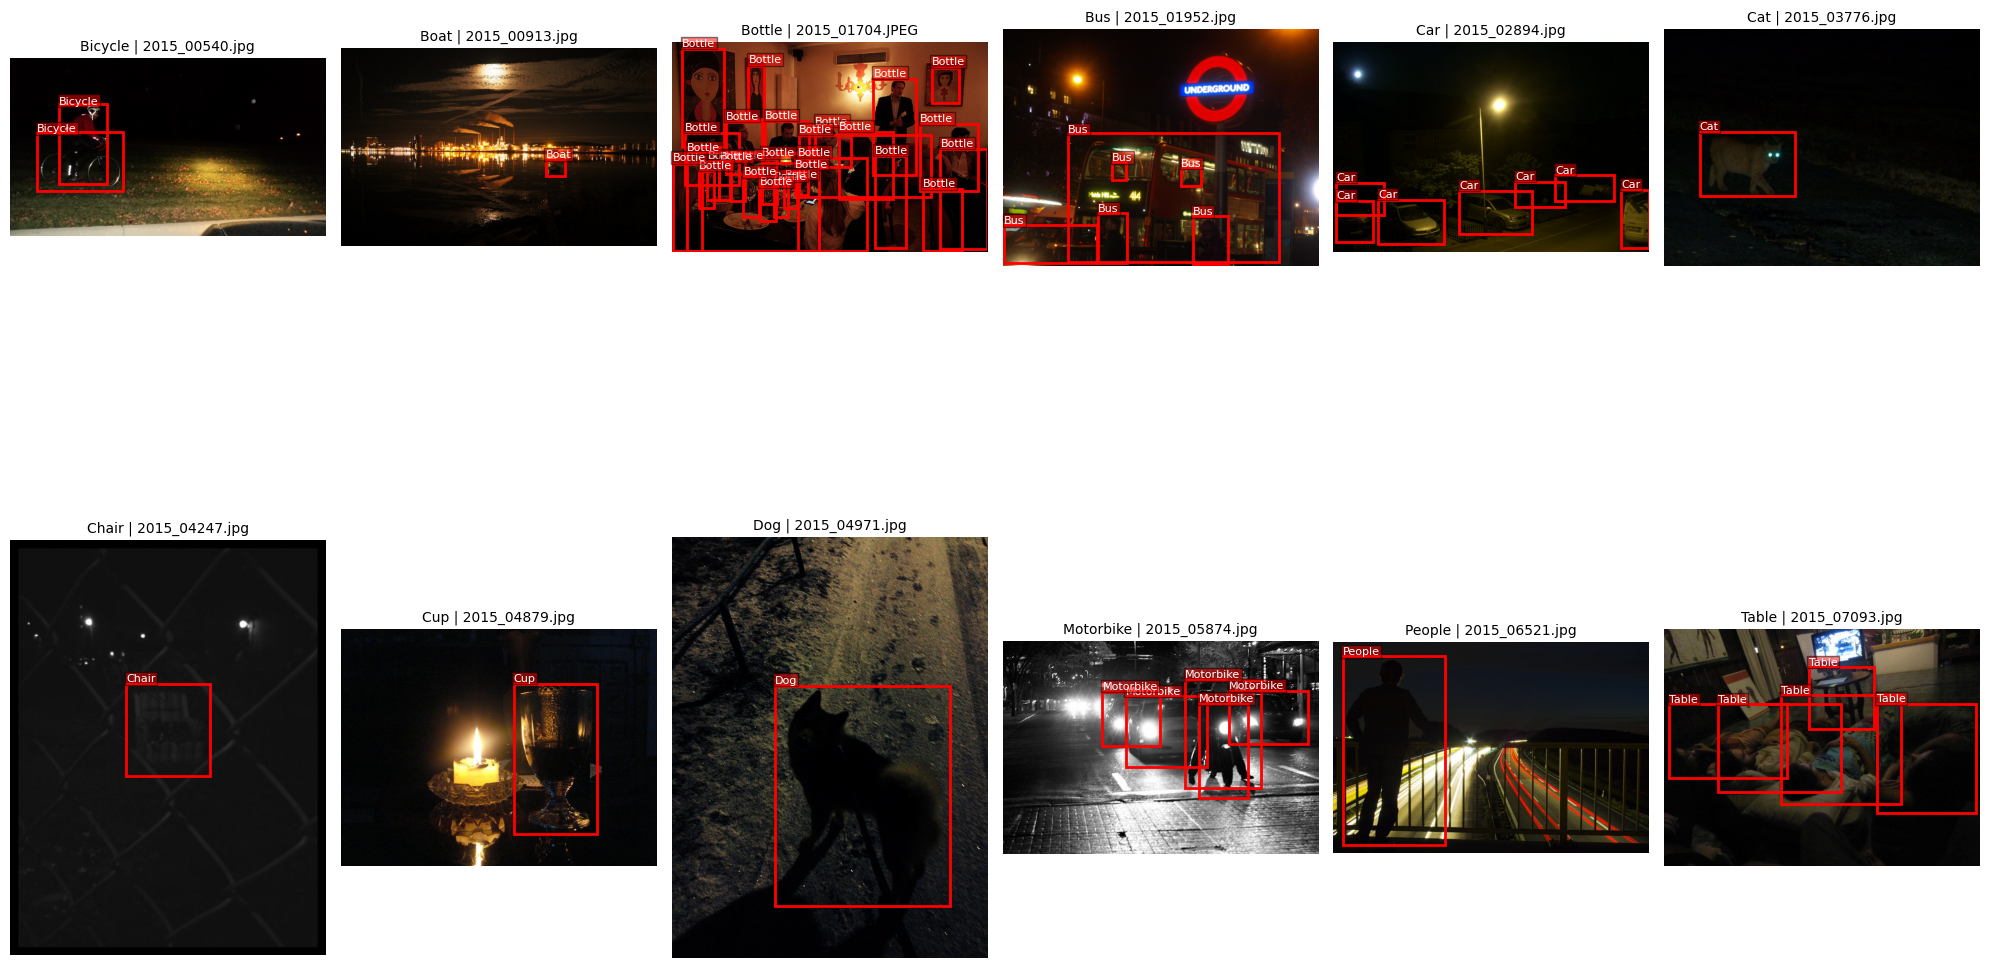

In [20]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def visualize_exdark_subplot(ax, class_name, img_root, annot_root):
    """
    Fetches a random image/annotation for a class and plots it on the provided Matplotlib axis (ax).
    """
    # 1. Construct paths
    class_img_dir = os.path.join(img_root, class_name)
    class_annot_dir = os.path.join(annot_root, class_name)
    
    # 2. Validation
    if not os.path.isdir(class_img_dir):
        ax.text(0.5, 0.5, f"Dir not found: {class_name}", ha='center')
        return

    files = [f for f in os.listdir(class_img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if not files:
        ax.text(0.5, 0.5, f"No images: {class_name}", ha='center')
        return
        
    # 3. Pick random file
    img_name = random.choice(files)
    img_path = os.path.join(class_img_dir, img_name)
    annot_name = f"{img_name}.txt"
    annot_path = os.path.join(class_annot_dir, annot_name)
    
    # 4. Load Image
    try:
        image = Image.open(img_path)
    except Exception as e:
        ax.text(0.5, 0.5, f"Err loading img", ha='center')
        return

    # 5. Load Annotations
    boxes = []
    if os.path.exists(annot_path):
        with open(annot_path, 'r') as f:
            lines = f.readlines()
            for line in lines:
                if line.startswith('%'): continue # Skip header
                parts = line.strip().split()
                if len(parts) >= 5:
                    try:
                        # ExDark Format: Class x y w h
                        x = float(parts[1])
                        y = float(parts[2])
                        w = float(parts[3])
                        h = float(parts[4])
                        boxes.append([x, y, w, h])
                    except ValueError:
                        continue

    # 6. Plotting on the passed 'ax'
    ax.imshow(image)
    ax.set_title(f"{class_name} | {img_name}", fontsize=10)
    ax.axis('off')

    # Draw boxes
    for box in boxes:
        x, y, w, h = box
        rect = patches.Rectangle(
            (x, y), w, h, 
            linewidth=2, 
            edgecolor='r', 
            facecolor='none'
        )
        ax.add_patch(rect)
        # Optional: Label
        ax.text(
            x, y - 5, 
            class_name, 
            color='white', 
            fontsize=8, 
            bbox=dict(facecolor='red', alpha=0.5, pad=1)
        )

# --- Main Execution ---
root_dir = r'data\exdark\ExDark'
annot_dir = r'data\exdark\ExDark_Annno'

# Get list of classes (dirs only)
classes = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
classes.sort()  # Sort alphabetically

# Create the Grid (6 rows, 2 columns)
rows, cols = 2, 6
fig, axes = plt.subplots(rows, cols, figsize=(20, 15))
axes = axes.flatten() # Flatten 2D array to 1D for easy iteration

print(f"Found {len(classes)} classes. Plotting...")

for i, ax in enumerate(axes):
    if i < len(classes):
        class_name = classes[i]
        visualize_exdark_subplot(ax, class_name, root_dir, annot_dir)
    else:
        # Hide unused subplots if classes < 12
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UnsupervisedLLIELoss(nn.Module):
    def __init__(self, weight_exp=10, weight_col=5, weight_tv=200, weight_spa=1):
        super(UnsupervisedLLIELoss, self).__init__()
        self.weight_exp = weight_exp
        self.weight_col = weight_col
        self.weight_tv = weight_tv
        self.weight_spa = weight_spa

    def forward(self, input_img, enhanced_img, illu_map):
        # input_img: The original low-light image
        # enhanced_img: The output of your model
        # illu_map: The light curve/map your model estimated (if applicable)
        
        loss_spa = self.spatial_consistency_loss(input_img, enhanced_img)
        loss_col = self.color_constancy_loss(enhanced_img)
        loss_exp = self.exposure_control_loss(enhanced_img)
        loss_tv = self.illumination_smoothness_loss(illu_map)
        
        total_loss = (self.weight_spa * loss_spa + 
                      self.weight_col * loss_col + 
                      self.weight_exp * loss_exp + 
                      self.weight_tv * loss_tv)
        return total_loss

    def spatial_consistency_loss(self, x, y):
        # Enforces that edges in Output (y) match edges in Input (x)
        # 1. Create 4 kernels for Up, Down, Left, Right neighbors
        kernel_left = torch.FloatTensor([[0,0,0],[-1,1,0],[0,0,0]]).cuda().unsqueeze(0).unsqueeze(0)
        kernel_right = torch.FloatTensor([[0,0,0],[0,1,-1],[0,0,0]]).cuda().unsqueeze(0).unsqueeze(0)
        kernel_up = torch.FloatTensor([[0,-1,0],[0,1,0],[0,0,0]]).cuda().unsqueeze(0).unsqueeze(0)
        kernel_down = torch.FloatTensor([[0,0,0],[0,1,0],[0,-1,0]]).cuda().unsqueeze(0).unsqueeze(0)

        # Average over channels to get 1-channel intensity
        x_mean = torch.mean(x, 1, keepdim=True)
        y_mean = torch.mean(y, 1, keepdim=True)

        d_org_left = F.conv2d(x_mean, kernel_left, padding=1)
        d_org_right = F.conv2d(x_mean, kernel_right, padding=1)
        d_org_up = F.conv2d(x_mean, kernel_up, padding=1)
        d_org_down = F.conv2d(x_mean, kernel_down, padding=1)

        d_enh_left = F.conv2d(y_mean, kernel_left, padding=1)
        d_enh_right = F.conv2d(y_mean, kernel_right, padding=1)
        d_enh_up = F.conv2d(y_mean, kernel_up, padding=1)
        d_enh_down = F.conv2d(y_mean, kernel_down, padding=1)

        d_left = torch.pow(d_org_left - d_enh_left, 2)
        d_right = torch.pow(d_org_right - d_enh_right, 2)
        d_up = torch.pow(d_org_up - d_enh_up, 2)
        d_down = torch.pow(d_org_down - d_enh_down, 2)
        
        return d_left.mean() + d_right.mean() + d_up.mean() + d_down.mean()

    def exposure_control_loss(self, x, mean_val=0.6):
        # Split into patches (e.g., 16x16) and force mean to be ~0.6
        x = torch.mean(x, 1, keepdim=True)
        mean = F.avg_pool2d(x, 16, stride=16)
        return torch.mean(torch.pow(mean - mean_val, 2))

    def color_constancy_loss(self, x):
        # Gray World Assumption: R, G, B means should be similar
        mean_rgb = torch.mean(x, [2, 3], keepdim=True)
        mr, mg, mb = torch.split(mean_rgb, 1, dim=1)
        d_rg = torch.pow(mr - mg, 2)
        d_rb = torch.pow(mr - mb, 2)
        d_gb = torch.pow(mg - mb, 2)
        return torch.sqrt(torch.pow(d_rg, 2) + torch.pow(d_rb, 2) + torch.pow(d_gb, 2)).mean()

    def illumination_smoothness_loss(self, x):
        # Total Variation on the Illumination Map
        # Ensures the light curve doesn't jitter
        batch_size = x.size()[0]
        h_x = x.size()[2]
        w_x = x.size()[3]
        count_h = (x.size()[2] - 1) * x.size()[3]
        count_w = x.size()[2] * (x.size()[3] - 1)
        
        h_tv = torch.pow((x[:,:,1:,:] - x[:,:,:h_x-1,:]), 2).sum()
        w_tv = torch.pow((x[:,:,:,1:] - x[:,:,:,:w_x-1]), 2).sum()
        
        return 2 * (h_tv / count_h + w_tv / count_w) / batch_size
